## EDA Operation 1 — Summary Statistics
Loads the dataset and computes descriptive statistics plus skewness and kurtosis for key audio features.

In [18]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "seaborn", "numpy"])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('spotify_cleaned.csv')

print("=== Descriptive Statistics ===")
print(df.describe().round(2))

print("\n=== Skewness and Kurtosis ===")
cols = ['popularity', 'danceability', 'energy', 'tempo', 'duration_minutes']
for col in cols:
    print(f"{col}: skewness={df[col].skew():.3f}, kurtosis={df[col].kurtosis():.3f}")
 

=== Descriptive Statistics ===
       popularity  danceability     energy        key   loudness       mode  \
count   113400.00     113400.00  113400.00  113400.00  113400.00  113400.00   
mean        33.33          0.57       0.64       5.31      -8.24       0.64   
std         22.29          0.17       0.25       3.56       5.01       0.48   
min          0.00          0.00       0.00       0.00     -49.53       0.00   
25%         17.00          0.46       0.47       2.00      -9.99       0.00   
50%         35.00          0.58       0.68       5.00      -6.99       1.00   
75%         50.00          0.70       0.85       8.00      -5.00       1.00   
max        100.00          0.98       1.00      11.00       4.53       1.00   

       speechiness  acousticness  instrumentalness   liveness    valence  \
count    113400.00     113400.00         113400.00  113400.00  113400.00   
mean          0.08          0.31              0.16       0.21       0.47   
std           0.11          0


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## EDA Operation 2 — Missingness and Zero-Popularity Analysis
Checks for remaining nulls and analyzes how many tracks have zero popularity.

In [19]:
print("=== Remaining Null Values ===")
print(df.isnull().sum())

zero_pct = 100 * df['is_zero_popularity'].sum() / len(df)
print(f"\nPercentage of zero-popularity tracks: {zero_pct:.1f}%")

print("\n=== Mean Popularity: Zero vs Non-Zero ===")
print(df.groupby('is_zero_popularity')['popularity'].mean())

=== Remaining Null Values ===
track_id              0
artists               0
album_name            0
track_name            0
popularity            0
explicit              0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
track_genre           0
duration_minutes      0
is_zero_popularity    0
dtype: int64

Percentage of zero-popularity tracks: 14.0%

=== Mean Popularity: Zero vs Non-Zero ===
is_zero_popularity
False    38.73949
True      0.00000
Name: popularity, dtype: float64


## EDA Operation 3 — Popularity Distribution
Histogram showing how popularity is spread across all tracks, with mean and median lines.

Saved: eda_plot_1.png


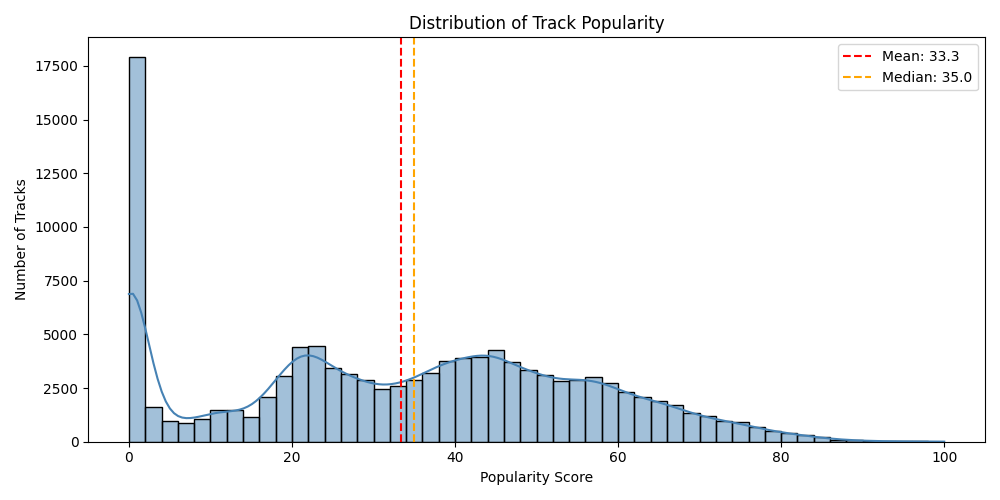

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, kde=True, color='steelblue')
plt.axvline(df['popularity'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['popularity'].mean():.1f}")
plt.axvline(df['popularity'].median(), color='orange', linestyle='--',
            label=f"Median: {df['popularity'].median():.1f}")
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.legend()
plt.tight_layout()
plt.savefig('eda_plot_1.png')
plt.close()
print("Saved: eda_plot_1.png")

from IPython.display import Image
Image('eda_plot_1.png')

## EDA Operation 4 — Clustered Correlation Heatmap
Shows how 8 audio features correlate with each other. Red = strong positive, Blue = strong negative.

Saved: eda_plot_2.png


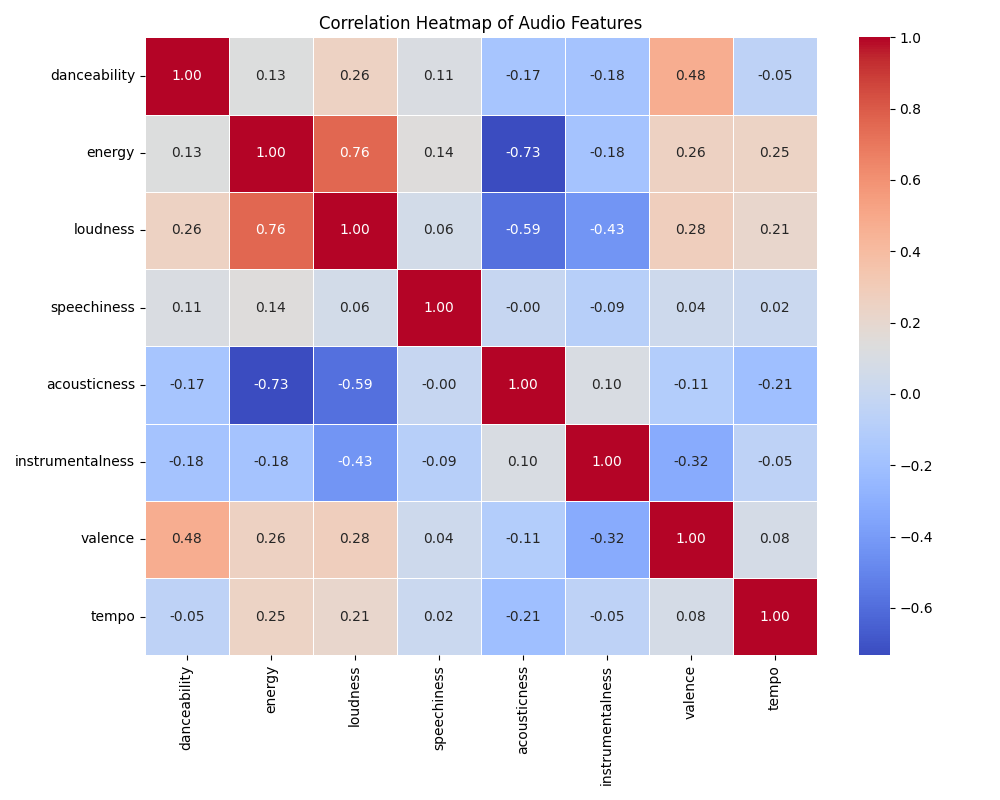

In [21]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'valence', 'tempo']

corr = df[audio_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features')
plt.tight_layout()
plt.savefig('eda_plot_2.png')
plt.close()
print("Saved: eda_plot_2.png")

from IPython.display import Image
Image('eda_plot_2.png')

## EDA Operation 5 — Top 15 Genres by Average Popularity
Horizontal bar chart showing which genres have the highest average popularity score.

Saved: eda_plot_3.png


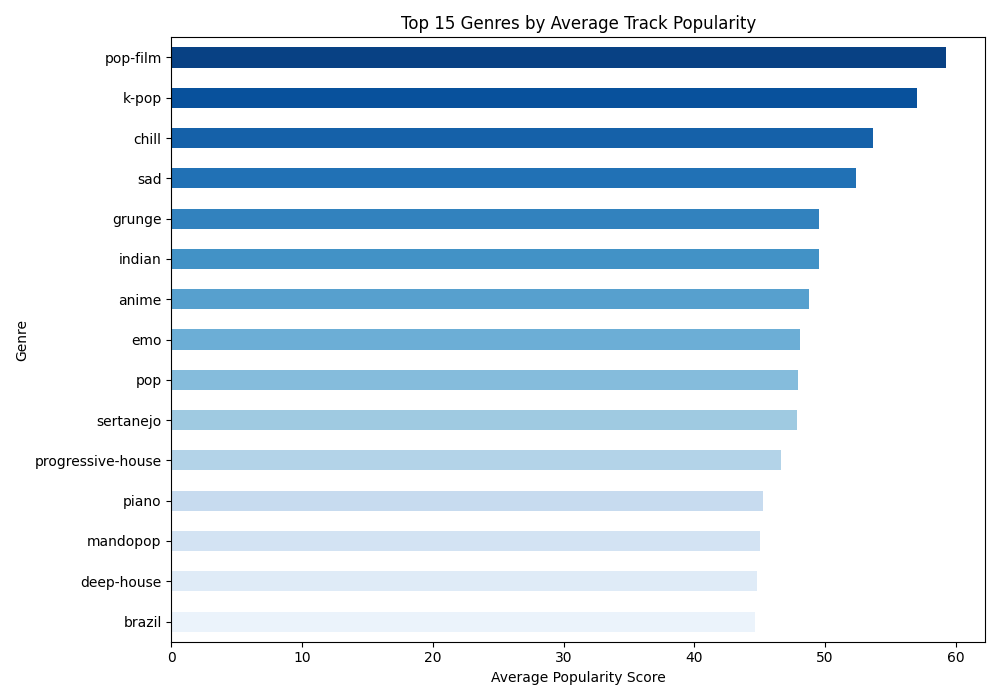

In [22]:
top_genres = (df.groupby('track_genre')['popularity']
              .mean()
              .sort_values(ascending=False)
              .head(15))

plt.figure(figsize=(10, 7))
colors = sns.color_palette("Blues_r", len(top_genres))
top_genres.plot(kind='barh', color=colors)
plt.title('Top 15 Genres by Average Track Popularity')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('eda_plot_3.png')
plt.close()
print("Saved: eda_plot_3.png")

from IPython.display import Image
Image('eda_plot_3.png')

## EDA Operation 6 — Audio Features by Popularity Group
Tracks split into Low/Medium/High popularity groups. 4 boxplots compare audio features across groups.

Saved: eda_plot_4.png


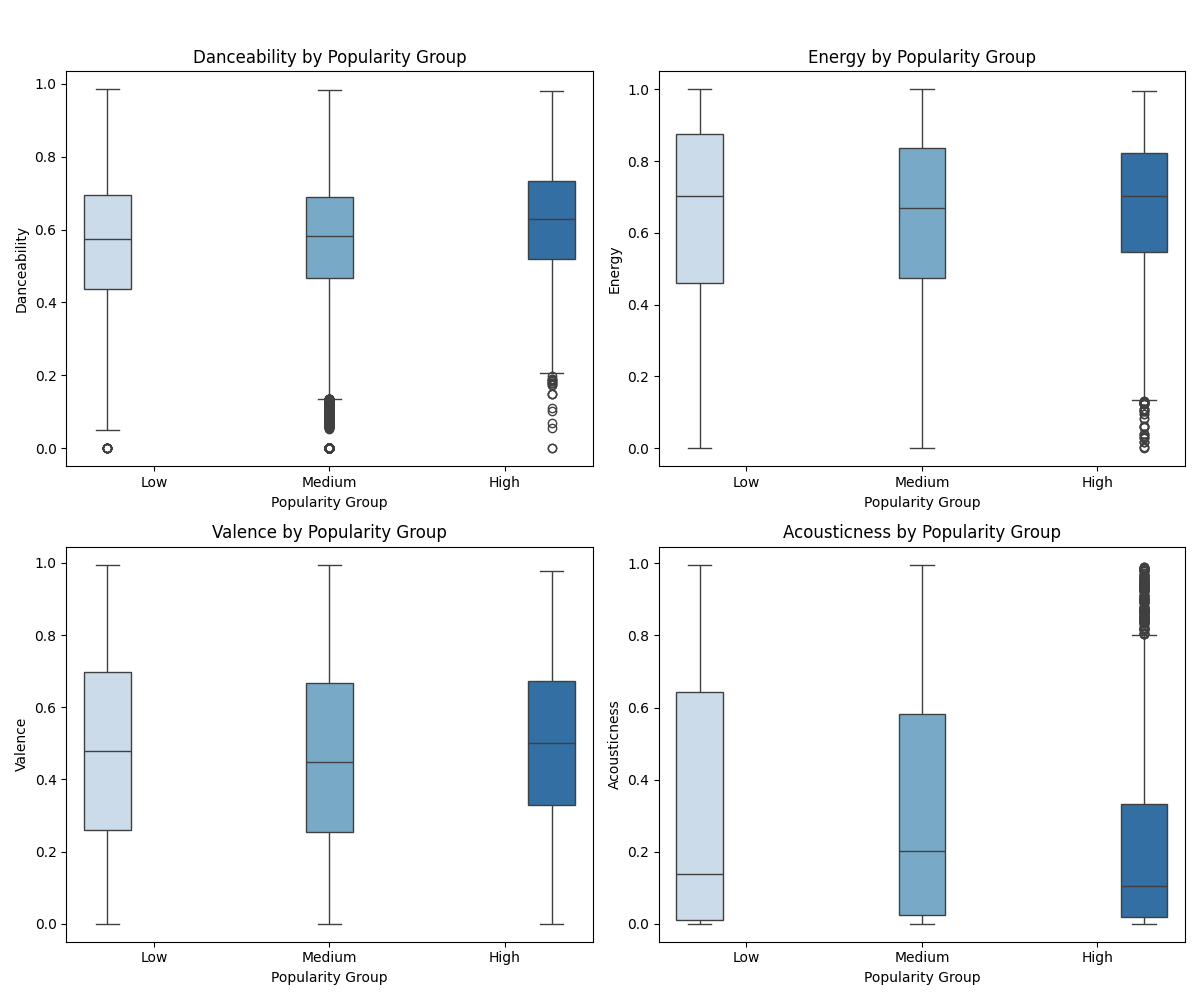

In [23]:
df['popularity_group'] = pd.cut(
    df['popularity'],
    bins=[0, 30, 70, 100],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

features = ['danceability', 'energy', 'valence', 'acousticness']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='popularity_group', y=feature, data=df, ax=axes[i],
                hue='popularity_group', palette='Blues', legend=False, orient='v')
    axes[i].set_title(f'{feature.capitalize()} by Popularity Group')
    axes[i].set_xlabel('Popularity Group')
    axes[i].set_ylabel(feature.capitalize())

plt.suptitle('Audio Feature Distribution by Popularity Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_plot_4.png')
plt.close()
print("Saved: eda_plot_4.png")

from IPython.display import Image
Image('eda_plot_4.png')